# 1. Dataset Exploration

Objectif : analyser les ventes de Lobster Mac & Cheese et préparer les données pour la prévision.

---

## Aperçu du dataset

- Chargement des données  
- Vérification des colonnes  
- Inspection des premières lignes  
- Contrôle des types (notamment la colonne temporelle)

---

## Colonne temporelle

- Vérifier que la date est bien présente  
- Convertir au format datetime  
- Détecter doublons ou irrégularités éventuelles

---

## Variable cible

- Examiner la distribution des ventes  
- Identifier valeurs manquantes ou aberrantes  
- Vérifier la cohérence des unités

---

## Préparation

- Nettoyage des noms de colonnes  
- Conversion des dates  
- Gestion des valeurs manquantes  
- Agrégation éventuelle (journalier, hebdomadaire)

---

## Résultat attendu

Un DataFrame contenant :
- `ds` : date  
- `y` : valeur à prédire  



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

In [9]:
df = pd.read_csv("../data/lobster_sales.csv")
df.head()

print(df.columns.tolist())

['TIMESTAMP', 'TOTAL_SOLD']


In [10]:
# Format pour Prophet

df = df.rename(
    columns={
        "TIMESTAMP": "ds",
        "TOTAL_SOLD": "y"
    }
)

df["ds"] = pd.to_datetime(df["ds"])

df.head()

,ds,y
0,2022-05-29,18
1,2022-05-30,11
2,2022-05-31,21
3,2022-06-01,11
4,2022-06-02,27


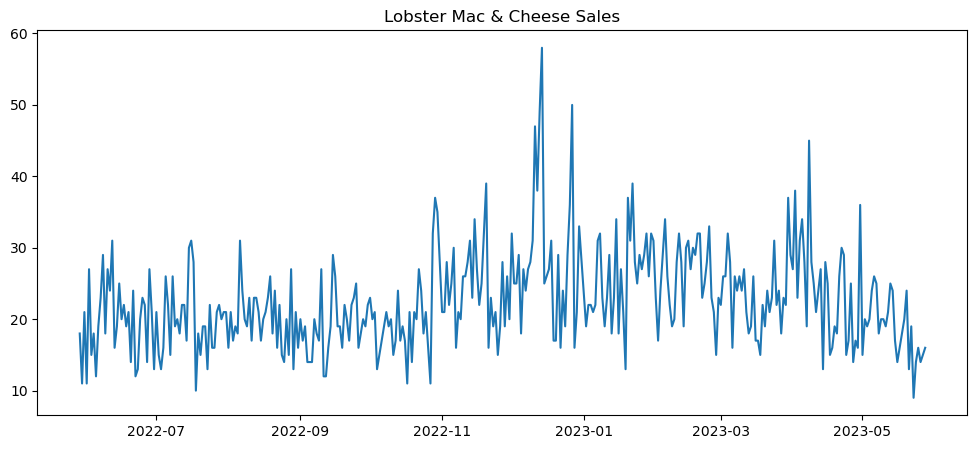

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"])
plt.title("Lobster Mac & Cheese Sales")
plt.show()

In [12]:
# 30 derniers j pour le test

train = df.iloc[:-30]
test = df.iloc[-30:]

print(len(train))
print(len(test))

333
30


# 2. Prophet

Dans cette section, nous entraînons un modèle Prophet sur les données historiques.

## Notes

Prophet est un modèle de séries temporelles développé par Facebook (Meta).  
Contrairement à Snowflake Forecast, il est entièrement documenté, interprétable et open‑source.

---

### Principe 

Prophet repose sur une décomposition additive de la série temporelle :

**Série temporelle = Tendance + Saisonnalité + Événements spéciaux + Bruit**

Formulation :



\[
y(t) = g(t) + s(t) + h(t) + \varepsilon_t
\]



Avec :

- **g(t)** : tendance  
- **s(t)** : saisonnalité  
- **h(t)** : jours fériés / événements  
- **εₜ** : bruit résiduel

---

### Composantes du modèle

#### Tendance (g(t))
Modélise l’évolution globale de la série :
- croissance linéaire ou logistique
- détection automatique des ruptures (changepoints)

#### Saisonnalité (s(t))
Gérée via des séries de Fourier :
- saisonnalité hebdomadaire
- saisonnalité annuelle
- saisonnalités personnalisées

#### Événements / jours fériés (h(t))
Permet d’intégrer :
- jours fériés nationaux
- événements métier (soldes, campagnes, vacances)
- effets ponctuels ou récurrents
- ....

#### Bruit (εₜ)
Part de la série non expliquée par les composantes précédentes.

---

### Intérêt

- Interprétable et modulaire  
- Robuste aux données manquantes et aux valeurs aberrantes  
- Adapté aux séries business (ventes, trafic, réservations)  
- Facile à ajuster (changepoints, régularisation, holidays)


In [13]:
# Train Prophet

model = Prophet()
model.fit(train)

17:16:32 - cmdstanpy - INFO - Chain [1] start processing
17:16:33 - cmdstanpy - INFO - Chain [1] done processing


## Comprendre Prophet (approche complémentaire)

Au‑delà de sa décomposition en tendance, saisonnalité et événements, Prophet se distingue surtout par sa philosophie de modélisation.  
Il a été conçu pour répondre à des besoins opérationnels courants : séries irrégulières, données manquantes, ruptures de tendance, effets calendaires, et contraintes métier.

Prophet se positionne comme un outil :
- robuste face aux données imparfaites,
- simple à ajuster sans expertise statistique avancée,
- capable de produire des prévisions cohérentes même avec peu d’historique,
- transparent dans ses choix (changepoints, saisonnalités, effets calendaires).

Contrairement aux systèmes AutoML de prévision, Prophet laisse le contrôle total sur :
- la définition des saisonnalités,
- l’ajout d’événements spécifiques,
- la gestion des ruptures,
- la régularisation du modèle.

Cette flexibilité permet d’intégrer des connaissances métier directement dans le modèle, ce qui est rarement possible avec des solutions automatisées comme Snowflake Forecast.

In [15]:
future = test[["ds"]]

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-29,24.616106,19.408231,34.593697,24.616106,24.616106,2.127110,2.127110,2.127110,2.127110,2.127110,2.127110,0.0,0.0,0.0,26.743216
1,2023-04-30,24.607501,20.110822,35.366218,24.607501,24.607501,3.087574,3.087574,3.087574,3.087574,3.087574,3.087574,0.0,0.0,0.0,27.695075
2,2023-05-01,24.598897,13.474805,28.453697,24.598897,24.599265,-3.698386,-3.698386,-3.698386,-3.698386,-3.698386,-3.698386,0.0,0.0,0.0,20.900511
3,2023-05-02,24.590292,17.430665,32.179795,24.589986,24.591968,0.209506,0.209506,0.209506,0.209506,0.209506,0.209506,0.0,0.0,0.0,24.799798
4,2023-05-03,24.581687,16.247572,31.084714,24.580173,24.585080,-0.865200,-0.865200,-0.865200,-0.865200,-0.865200,-0.865200,0.0,0.0,0.0,23.716487


In [16]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')

## Sortie de Prophet

Après l’entraînement du modèle, Prophet renvoie un DataFrame `forecast` contenant plusieurs colonnes.  
Elles permettent d’aller bien au‑delà d’une simple valeur prédite.

### Colonnes 

- **ds** : date de la prédiction  
- **yhat** : valeur prédite  
- **yhat_lower / yhat_upper** : intervalle de confiance  
- **trend** : estimation de la tendance sous‑jacente  
- **trend_lower / trend_upper** : incertitude sur la tendance  

D’autres colonnes peuvent apparaître selon les options activées (saisonnalités, holidays, etc.).

### Intérêt 

Contrairement à un système de prévision automatisé qui renvoie uniquement une valeur (ex. Snowflake Forecast), Prophet fournit :

- une prédiction,
- un intervalle d’incertitude,
- une estimation de la tendance,
- et des composantes séparées si on les demande.

Cela permet d’interpréter la prévision, de comprendre ce qui influence le modèle et d’évaluer la stabilité du signal.

### Simplifions

Snowflake pourrait renvoyer :  
**Prévision = 42**

Prophet renvoie :  
- **yhat = 42**  
- **intervalle = [38 ; 47]**  
- **trend = 39**  

Ce niveau de détail permet une analyse plus fine et une meilleure prise de décision.
